In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np
import matplotlib.pyplot as plt
import time

In [51]:
data = np.genfromtxt("Seed_Data.csv", delimiter=",", skip_header=1)

X = data[:, :-1]
y = data[:, -1].astype(int)

print("X shape:", X.shape)
print("Sınıflar:", np.unique(y))

X shape: (210, 7)
Sınıflar: [0 1 2]


In [52]:
# Train ve Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, y_train.shape)
print("Test shape :", X_test_scaled.shape, y_test.shape)

Train shape: (168, 7) (168,)
Test shape : (42, 7) (42,)


In [53]:

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,        dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test,        dtype=torch.long)

In [54]:
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

INPUT_SIZE = X_train_tensor.shape[1]     
OUTPUT_SIZE = len(np.unique(y))           
EPOCHS = 100

In [55]:
def train_and_get_stats(model, name, color):
    print(f"   -> {name} eğitiliyor...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    loss_history = []
    start_time = time.time()
    
    # Eğitim döngüsü
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))
    
    duration = time.time() - start_time
    
    # Test doğruluğu
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs, 1)
        accuracy = (predicted == y_test_tensor).float().mean().item()
        
    return {
        "name": name,
        "accuracy": accuracy,
        "time": duration,
        "loss_history": loss_history,
        "color": color,
        "model_obj": model
    }

In [56]:
class MLPModel1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_SIZE, 16),  
            nn.ReLU(),                  
            nn.Linear(16, OUTPUT_SIZE)  
        )

    def forward(self, x):
        return self.net(x)

model1 = MLPModel1()
model1

stats1 = train_and_get_stats(model1, "Model 1 (1 hidden layer)", "blue")

print("Model 1 doğruluk (accuracy):", stats1["accuracy"])
print("Model 1 eğitim süresi (sn):", stats1["time"])

   -> Model 1 (1 hidden layer) eğitiliyor...
Model 1 doğruluk (accuracy): 0.8571428656578064
Model 1 eğitim süresi (sn): 0.28546595573425293


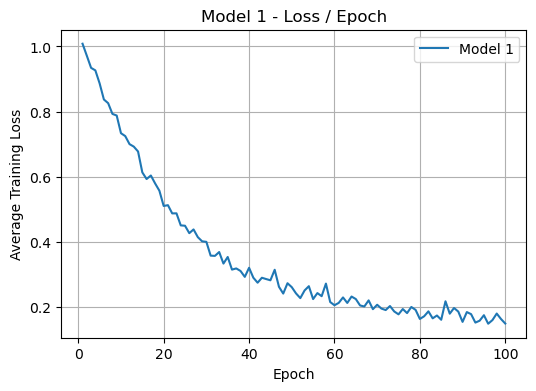

In [57]:
plt.figure(figsize=(6,4))
plt.plot(range(1, EPOCHS+1), stats1["loss_history"], label="Model 1")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Model 1 - Loss / Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
class MLPModel2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_SIZE, 32),  
            nn.ReLU(),
            nn.Linear(32, 16),        
            nn.ReLU(),
            nn.Linear(16, OUTPUT_SIZE)  
        )

    def forward(self, x):
        return self.net(x)

model2 = MLPModel2()
stats2 = train_and_get_stats(model2, "Model 2 (2 hidden layers)", "red")

print("Model 2 doğruluk (accuracy):", stats2["accuracy"])
print("Model 2 eğitim süresi (sn):", stats2["time"])

   -> Model 2 (2 hidden layers) eğitiliyor...
Model 2 doğruluk (accuracy): 0.8333333134651184
Model 2 eğitim süresi (sn): 0.23809814453125


In [59]:
class MLPModel3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_SIZE, 64),  # 7 → 64
            nn.ReLU(),
            nn.Linear(64, 32),          # 64 → 32
            nn.ReLU(),
            nn.Linear(32, 16),          # 32 → 16
            nn.ReLU(),
            nn.Linear(16, OUTPUT_SIZE)  # 16 → 3
        )

    def forward(self, x):
        return self.net(x)

model3 = MLPModel3()
stats3 = train_and_get_stats(model3, "Model 3 (3 hidden layers)", "green")

print("Model 3 doğruluk (accuracy):", stats3["accuracy"])
print("Model 3 eğitim süresi (sn):", stats3["time"])

   -> Model 3 (3 hidden layers) eğitiliyor...
Model 3 doğruluk (accuracy): 0.8333333134651184
Model 3 eğitim süresi (sn): 0.27601194381713867


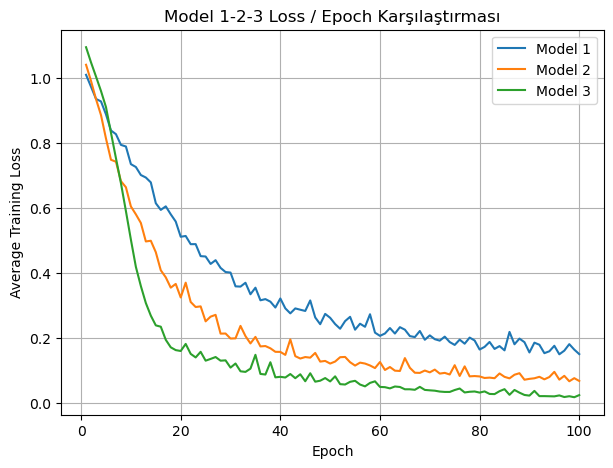

In [60]:
plt.figure(figsize=(7,5))
plt.plot(range(1, EPOCHS+1), stats1["loss_history"], label="Model 1")
plt.plot(range(1, EPOCHS+1), stats2["loss_history"], label="Model 2")
plt.plot(range(1, EPOCHS+1), stats3["loss_history"], label="Model 3")
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Model 1-2-3 Loss / Epoch Karşılaştırması")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
models_stats = [stats1, stats2, stats3]

print("Model Numarası | Accuracy (Test) | Eğitim Süresi (sn)")
print("-----------------------------------------------------")
for i, s in enumerate(models_stats, start=1):
    print(f"{i:<13} | {s['accuracy']:.4f}        | {s['time']:.4f}")

Model Numarası | Accuracy (Test) | Eğitim Süresi (sn)
-----------------------------------------------------
1             | 0.8571        | 0.2855
2             | 0.8333        | 0.2381
3             | 0.8333        | 0.2760


In [62]:
models_stats = [stats1, stats2, stats3]
best = max(models_stats, key=lambda s: s["accuracy"])

print("En iyi model:", best["name"])
print("Accuracy:", best["accuracy"])

En iyi model: Model 1 (1 hidden layer)
Accuracy: 0.8571428656578064


In [63]:
best_name = best["name"]
print("Best name:", best_name)

if "Model 1" in best_name:
    hidden_sizes = [16]              
elif "Model 2" in best_name:
    hidden_sizes = [32, 16]         
elif "Model 3" in best_name:
    hidden_sizes = [64, 32, 16]     
else:
    raise ValueError("Best model is unknown, isim eşleşmedi.")
    
print("Seçilen gizli katman boyutları:", hidden_sizes)

Best name: Model 1 (1 hidden layer)
Seçilen gizli katman boyutları: [16]


In [65]:
class BestModel(nn.Module):
    def __init__(self, act_func=nn.ReLU()):
        super().__init__()
        self.act = act_func
        
        # Dinamik olarak katmanları oluştur
        self.layers = nn.ModuleList()
        in_features = INPUT_SIZE
        
        for h in hidden_sizes:
            self.layers.append(nn.Linear(in_features, h))
            in_features = h
        
        # Çıkış katmanı
        self.output = nn.Linear(in_features, OUTPUT_SIZE)

    def forward(self, x):
        # Her gizli katmanda aynı aktivasyonu kullan
        for layer in self.layers:
            x = self.act(layer(x))
        x = self.output(x)
        return x

In [66]:
print(f"En iyi model: {best['name']} seçildi. Tanh ve Sigmoid ile tekrar eğitiliyor...")

# Tanh ile eğit
res_tanh = train_and_get_stats(
    BestModel(act_func=nn.Tanh()),
    "Aktivasyon: Tanh",
    "purple"
)

# Sigmoid ile eğit
res_sigm = train_and_get_stats(
    BestModel(act_func=nn.Sigmoid()),
    "Aktivasyon: Sigmoid",
    "orange"
)

activation_results = [best, res_tanh, res_sigm]

print("\nAktivasyon karşılaştırma sonuçları:")
for r in activation_results:
    print(f"{r['name']:<25} | Accuracy: {r['accuracy']:.4f} | Süre: {r['time']:.4f} sn")

En iyi model: Model 1 (1 hidden layer) seçildi. Tanh ve Sigmoid ile tekrar eğitiliyor...
   -> Aktivasyon: Tanh eğitiliyor...
   -> Aktivasyon: Sigmoid eğitiliyor...

Aktivasyon karşılaştırma sonuçları:
Model 1 (1 hidden layer)  | Accuracy: 0.8571 | Süre: 0.2855 sn
Aktivasyon: Tanh          | Accuracy: 0.8810 | Süre: 0.2042 sn
Aktivasyon: Sigmoid       | Accuracy: 0.8333 | Süre: 0.1756 sn


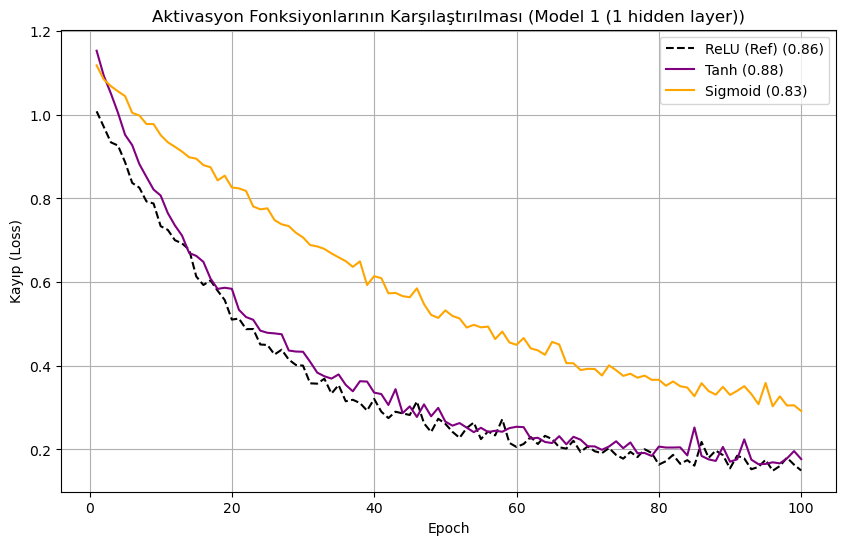

In [67]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, EPOCHS+1), best['loss_history'],
         color='black', linestyle='--',
         label=f"ReLU (Ref) ({best['accuracy']:.2f})")
plt.plot(range(1, EPOCHS+1), res_tanh['loss_history'],
         color='purple',
         label=f"Tanh ({res_tanh['accuracy']:.2f})")
plt.plot(range(1, EPOCHS+1), res_sigm['loss_history'],
         color='orange',
         label=f"Sigmoid ({res_sigm['accuracy']:.2f})")

plt.title(f"Aktivasyon Fonksiyonlarının Karşılaştırılması ({best['name']})")
plt.xlabel("Epoch")
plt.ylabel("Kayıp (Loss)")
plt.legend()
plt.grid(True)
plt.show()